# Python Parallel Computing - Part 02

### Lecture 11

### Apr 15, 2026

Based on material here: https://nyu-cds.github.io/python-mpi/ (parts 4/5).


---
### Problem Decomposition
A central problem when working with MPI is to break the problem into “chunks” to be handled by individual processes so thet can work on the problem simultaneously. 

This is known as decomposition or partitioning.

There are two main ways to decompose a problem: 

- __Domain decomposition:__ Data associated with a problem is split into chunks and each parallel process works on a chunk of the data.
- __Functional decomposition:__ Focus is on the computation rather than on the data. Used when pieces of data require different processing.

---

<img src="domain_decomp.png" style="width: 800px;"/>

<img src="funct_decomp.png" style="width: 1000px;"/>

---

#### Example of a domain decompostion with MPI





**Hermite interpolation:**

Concretelly, for example, we want to interpolate $$p(x) = ax^3+bx^2+cx+d$$ where $$p'(x) = 3ax^2 + 2b x + c$$ 


and have the following estimates: $y_0 = p(x_0), y_1 = p(x_1)$ and $m_0 = p'(x_0), m_1 = p'(x_1)$.



<img src="img8.png" alt="Drawing" style="width: 300px;"/>

$$
\begin{array}{l}
ax_0^3+bx_0^2+cx_0+d = y_0\\
ax_1^3+bx_1^2+cx_1+d = y_1\\
3ax_0^2+2bx_0+c = m_0\\
3ax_1^2+2bx_1+c = m_1
\end{array}
\Longrightarrow
\left[\begin{array}{cccc}
x_0^3 & x_0^2 & x_0 & 1\\
x_1^3 & x_1^2 & x_1 & 1\\
3x_0^2 & 2x_0 & 1 & 0\\
3x_1^2 & 2x_1 & 1 & 0
\end{array}\right]
\left[\begin{array}{c}
a\\
b\\
c\\
d
\end{array}\right]=
\left[\begin{array}{c}
y_0\\
y_1\\
m_0\\
m_1
\end{array}\right]
$$

In [1]:
import numpy as np

def hermite(data):
    """
    data in the form: [x[i], x[i+1], y[i], y[i+1], m[i], m[i+1]]
    - x[i], y[i] = point 1
    - x[i+1], y[i+1] = point 2
    - m[i], m[i+1] = slopes (derivatives)
    """
    
    A = np.zeros((4,4))
    pts = []

    #create A and b for the linear system
    A[0:2] = np.array([np.power(data[0:2], 3), np.power(data[0:2], 2), data[0:2],np.array([1,1])]).T
    A[2:4] = np.array([3*np.power(data[0:2],2), 2*data[0:2],np.array([1,1]), np.array([0,0])]).T
    b = data[2: ]
    
    #solve the linear system A * coefs = b 
    coefs = np.linalg.solve(A, b)
    
    # interpolate polynomial on [x[i], x[i+1]] in 100 points
    t = np.linspace(data[0], data[1], 100)
    pts.extend(np.polyval(coefs, t))
    
    return pts 

Took 0.2974238395690918s


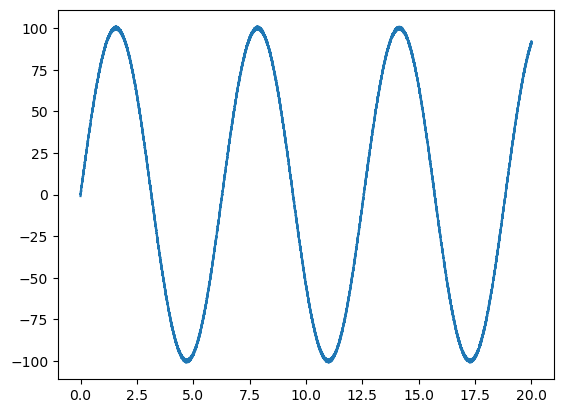

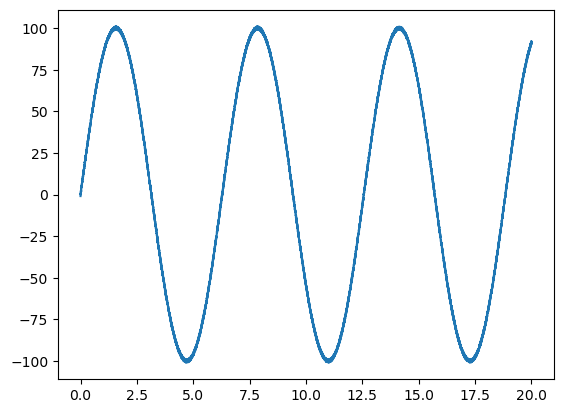

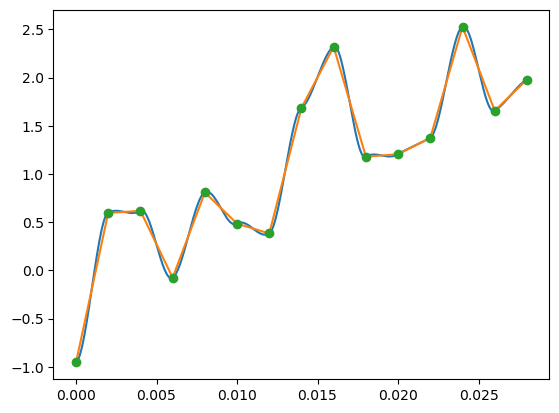

In [2]:
#####
# Finding the piece-wise hermite polynomial interpolation of a set of points
# Sequential version
#####

from time import time
import numpy as np
import matplotlib.pyplot as plt

ts = time()
numx = 10000   # number of discretized points in x

x = np.linspace(0, 20, numx)
y = np.random.uniform(low=-1,high=1, size=numx) + 100 * np.sin(x)
m = np.random.uniform(low=-1, high=1, size=numx) + 100 * np.cos(x)

l = []
for i in range(numx - 1):
    data = np.array([x[i], x[i+1], y[i], y[i+1], m[i], m[i+1]])
    l.extend(hermite(data))
   

print('Took {}s'.format(time() - ts))

plt.figure()
plt.plot(x, y)

s = np.linspace(0, 20, len(l))
plt.figure()
plt.plot(s, l)

plt.figure()
end = 15
plt.plot(s[0:100*(end-1)], l[0:100*(end-1)])
plt.plot(x[0:end], y[0:end])
plt.plot(x[0:end], y[0:end],'o')
plt.show()



In [3]:
%%writefile mpi08.py
#####
# Finding the piece-wise hermite polynomial interpolation of a set of points
# MPI version
#####
from time import time
import numpy as np
import matplotlib.pyplot as plt
import numpy
from mpi4py import MPI

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()
status = MPI.Status()

ts = time()
numx = 10_000
rank_interval_size = 20 / size
numx_per_rank = int(np.floor(numx / size))

m = np.zeros((numx_per_rank,))

# same as the previous hermite function
def hermite(data):
    A = np.zeros((4, 4))
    pts = []

    A[0:2]=np.array([np.power(data[0:2], 3),np.power(data[0:2],2),data[0:2],np.array([1,1])]).T
    A[2:4]=np.array([3*np.power(data[0:2],2),2*data[0:2],np.array([1,1]),np.array([0,0])]).T
    b = data[2:]
    coefs = np.linalg.solve(A,b)
    t = np.linspace(data[0], data[1], 100)
    pts.extend(np.polyval(coefs,t))
    return(pts)


if rank == 0:
    l = []
    x = np.linspace(0, rank_interval_size, numx_per_rank)
    y = np.random.uniform(low=-1, high=1, size=numx_per_rank) + 100 * np.sin(x)
    for i in range(numx_per_rank-1):
        data = np.array([x[i], x[i+1], y[i], y[i+1], m[i], m[i+1]])
        l.extend(hermite(data))
        
    # Process 0 serves also as receiver
    pts = np.zeros((np.asarray(l).shape[0], ))
    for p in range(1, size):
        comm.Recv(pts, source=p)
        l.extend(np.ndarray.tolist(pts))
    
    np.save('mpi_hermite_cpt.npy', np.asarray([x, y]))
    np.save('mpi_hermite.npy', np.asarray(l))

else:
    l = []
    x = np.linspace(rank*rank_interval_size,(rank + 1)*rank_interval_size, numx_per_rank)
    y = np.random.uniform(low=-1,high=1, size=numx_per_rank) + 100 * np.sin(x)
    for i in range(numx_per_rank-1):
        data = np.array([x[i], x[i+1], y[i], y[i+1], m[i], m[i+1]])
        l.extend(hermite(data))
    
    pts = np.asarray(l) 
    comm.Send(pts,dest=0)
    
print('Rank ',rank,' Took {}s'.format(time() - ts))

Overwriting mpi08.py


In [4]:
!mpiexec -n 4 python3 mpi08.py

Rank  1  Took 0.10711908340454102s
Rank  2  Took 0.11214518547058105s
Rank  3  Took 0.12066793441772461s
Rank  0  Took 0.17136120796203613s


(2, 2500) (999600,)


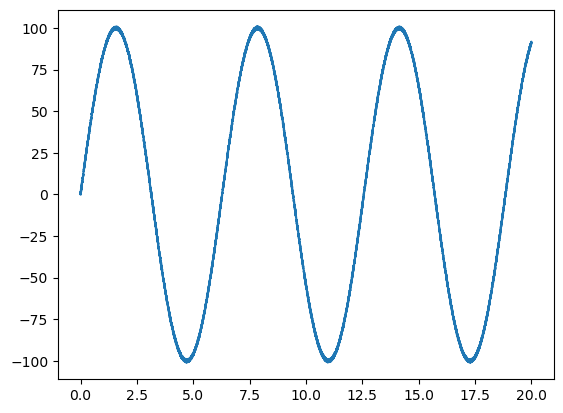

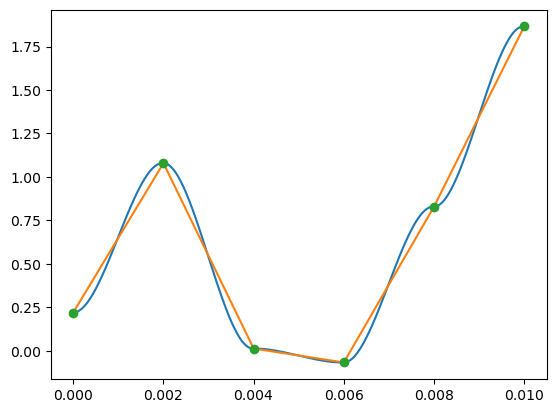

In [5]:
cpt = np.load('mpi_hermite_cpt.npy')    # control points
r = np.load('mpi_hermite.npy')
print(cpt.shape, r.shape)

s = np.linspace(0, 20, r.shape[0])
plt.figure(1)
plt.plot(s, r)
plt.figure(2)
plt.plot(s[0:500],r[0:500])
plt.plot(cpt[0,0:6], cpt[1,0:6])
plt.plot(cpt[0,0:6], cpt[1,0:6],'o')
plt.show()

---
## Collective Operations: point-to-point vs collective communication

- There are many situations in parallel programming when groups of processes need to exchange messages. <br><br> 
- Rather than explicitly sending and receiving such messages as we have been doing, the real power of MPI comes from group operations known as **collectives**. <br><br>



__Collective communication__ allows to send data between multiple processes of a group simultaneously and the most common operations are:  <br><br>

- **Synchronization** <br><br>
  - Processes wait until all members of the group have reached the synchronization point <br><br>
- **Global communication functions** <br><br>
  - Broadcast data from one member to all members of a group <br><br>
  - Gather data from all members to one member of a group <br><br>
  - Scatter data from one member to all members of a group <br><br>
- **Collective computation (reductions)** <br><br>
  - One member of the group collects data from the other members and performs an operation (min, max, add, multiply, etc.) on that data. <br><br>
- **Collective Input/Output** <br><br>
  - Each member of the group reads or writes a section of a file. <br><br>

#### **Synchronization**

- One of the things to remember about collective communication is that it implies a synchronization point among processes. <br><br>
- This means that all processes must reach a point in their code before they can all begin executing again. <br><br>

- MPI has a special function that is dedicated to synchronizing processes: `comm.Barrier()`.  <br><br>
- No process advances until all have called the function. <br><br>
$$
\begin{array}{cc|c}
& \bigcirc & \\
\bigcirc& 	 & \\
& 	\bigcirc & 
\end{array}
\Rightarrow
\begin{array}{cc|c}
& \bigcirc & \\
& \bigcirc	 & \\
& 	\bigcirc & 
\end{array}
\Rightarrow
\begin{array}{cc|c}
& &\bigcirc  \\
& &\bigcirc	  \\
& &	\bigcirc  
\end{array}
$$


<img src="comm_barrier.png" style="width: 400px;"/>

- Process zero first calls Barrier at the first time snapshot (T1).  <br><br>
- While process zero is hung up at the barrier, process one and three eventually make it (T2).  <br><br>
- When process two finally makes it to the barrier (T3), all of the processes then begin execution again (T4). <br><br>

---

### Global communication functions

For detailed diagrams see: [https://nyu-cds.github.io/python-mpi/05-collectives/](https://nyu-cds.github.io/python-mpi/05-collectives/)

Examples here: https://mpi4py.readthedocs.io/en/stable/tutorial.html#collective-communication

---




#### **Broadcasting**

- A broadcast is one of the standard collective communication techniques. <br><br>
- During a broadcast, one process sends the same data to all processes in a communicator.  <br><br>
- One of the main uses of broadcasting is to send out user input to a parallel program, or send out configuration parameters to all processes. <br><br>

One process sends the same data to all processes in a communicator using the command `comm.Bcast(buf, root=0)`. <br><br>


<img src="broadcast.png" style="width: 400px;"/>

- In this example, process zero is the root process, and it has the initial copy of data.  <br><br>
- All of the other processes receive the copy of data. <br><br>


#### **Scatter**

- Scatter is a collective operation that is very similar to broadcast.  <br><br>
- Scatter involves a designated root process sending data to all processes in a communicator. <br><br> 
- The primary difference between broadcast and scatter is small but important.  <br><br>
  - Broadcast sends the same piece of data to all processes while scatter sends chunks of an array to different processes. <br><br>



Broadcast sends the same piece of data to all processes while scatter sends chunks of an array to different processes. 


<img src="scatter.png" style="width: 400px;"/>


- In the previous illustration, the broadcast takes a single data element at the root process (the red box) and copies it to all other processes.  <br><br>
- However the scatter takes an array of elements and distributes the elements in the order of process rank.  <br><br>
- The first element (in red) goes to process zero, the second element (in green) goes to process one, and so on.  <br><br>
- Although the root process (process zero) contains the entire array of data, the scatter operation will copy the appropriate element into the receiving buffer of the process. <br><br>


`Comm.Scatter(sendbuf, recvbuf, root=0)` method takes three arguments. 

- The first is an array of data that resides on the root process.  <br><br>
- The second parameter is used to hold the received data.  <br><br>
- The last parameter indicates the root process that is scattering the array of data. <br><br>


#### **Gather**
Gather is the inverse of scatter, taking elements from many processes and gathering them to one single process.

<img src="gather.png" style="width: 400px;"/>

`Comm.Gather(sendbuf, recvbuf, root=0)` method takes the same arguments as __Comm.Scatter__.


#### **Reduction**

- Data reduction involves reducing a set of numbers into a smaller set of numbers via a function.  <br><br>
  - For example, let’s say we have a list of numbers [1, 2, 3, 4, 5]. Reducing this list of numbers with the sum function would produce sum([1, 2, 3, 4, 5]) = 15. Similarly, the multiplication reduction would yield multiply([1, 2, 3, 4, 5]) = 120.



__Comm.Reduce(sendbuf, recvbuf, op=MPI.SUM, root=0)__ handles almost all of the common reductions that a programmer needs to do in a parallel application. <br><br>

<img src="reduction.png" style="width: 400px;"/>

- In the above, each process contains one integer.  <br><br>
- The reduction operation is called with a root process of 0 and using MPI_SUM as the reduction operation.  <br><br>
- The four numbers are summed to the result and stored on the root process. <br><br>

__Comm.Reduce__ takes an array of input elements and returns an array of reduced elements to the root process.
- `MPI.MAX` - Returns the maximum element. <br><br>
- `MPI.MIN` - Returns the minimum element. <br><br>
- `MPI.SUM` - Sums the elements. <br><br>
- `MPI.PROD` - Multiplies all elements. <br><br>

#### **Other Colletive Operations**
- `Comm.Alltoall(sendbuf, recvbuf)`
- `File.Open(comm, filename, amode, info)`
- `File.Write_all(buffer)`

---
#### Computing an integral using parallel collective version 

In [6]:
%%writefile mpi09.py
import numpy as np
from math import sin
from mpi4py import MPI

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

def integral(a_r, h, n):
    integ = 0.0
    for j in range(n):
        t = a_r + (j + 0.5) * h
        integ += sin(t) * h
    return integ


a = 0.0
b = np.pi / 2
root_process = 0
my_int = np.zeros(1)
integral_sum = np.zeros(1)

# Initialize value of n only if this is rank 0
if rank == 0:
    n = np.full(1, 500, dtype=int) # default value
else:
    n = np.zeros(1, dtype=int)

# Broadcast n to all processes
print("Process ", rank, " before n =", n[0], flush=True)
comm.Bcast(n, root=root_process)
print("Process ", rank, " after n =", n[0], flush=True)

# Compute partition
h = (b - a) / (n[0] * size) # calculate h *after* we receive n
a_r = a + rank * h * n[0]
my_int[0] = integral(a_r, h, n[0])

# Send partition back to root process, computing sum across all partitions
print("Process ", rank, " has the partial integral ", my_int[0], flush=True)
comm.Reduce(my_int, integral_sum, MPI.SUM, root_process)

# Only print the result in process 0
if rank == 0:
    print('The Integral Sum =', integral_sum[0], flush=True)

Overwriting mpi09.py


In [7]:
!mpiexec -n 4 python mpi09.py

Process  3  before n = 0
Process  2  before n = 0
Process  1  before n = 0
Process  0  before n = 500
Process  0  after n = 500
Process  2  after n = 500
Process  1  after n = 500
Process  3  after n = 500
Process  0  has the partial integral  Process  1  has the partial integral  Process  2  has the partial integral  0.32442335715981740.07612046944516872
0.216772756896253

Process  3  has the partial integral  0.38268344220085593
The Integral Sum = 1.0000000257020951


### Matrix-vector multiplication

Parallelize $y = Ax$ over the rows of $A$.

$$
\begin{pmatrix}y_1 \\ \vdots \\ y_k \end{pmatrix} = \begin{pmatrix}A_1 \\ \vdots \\ A_k \end{pmatrix} x
$$

In [8]:
%%writefile mpimatvec.py

from mpi4py import MPI
import numpy as np

comm = MPI.COMM_WORLD
size = comm.Get_size()
rank = comm.Get_rank()

n = size * 2
m = 5
if rank == 0:
    A = np.random.randn(n, m)
    x = np.random.randn(m)

    ytarget = A.dot(x) # to check the result
    
    A = A.reshape(size, -1, m)
else:
    A = None
    x = np.zeros(m)

Asmall = np.zeros((n // size, m))

# Asmall = comm.scatter(A, root=0)
comm.Scatter(A, Asmall, root=0)

# x = comm.bcast(x, root=0)
comm.Bcast(x, root=0)

print('rank', rank, ':', Asmall.shape, x.shape, flush=True)

ysmall = Asmall.dot(x)

# y = comm.gather(ysmall, root=0)
y = np.zeros((size, n // size))
comm.Gather(ysmall, y, root=0)

if rank == 0:
    print(np.concatenate(y), flush=True)
    print(ytarget, flush=True)


Overwriting mpimatvec.py


In [9]:
!mpiexec -n 4 python mpimatvec.py

rank 0 : (2, 5) (5,)
rank 1 : (2, 5) (5,)
rank 2 : (2, 5) (5,)
rank 3 : (2, 5) (5,)
[ 0.259178    0.78774781 -1.43556207 -0.58051079  1.29114257 -0.33135906
 -0.41899241  1.12960211]
[ 0.259178    0.78774781 -1.43556207 -0.58051079  1.29114257 -0.33135906
 -0.41899241  1.12960211]


In [10]:
import numpy as np
A = np.random.randn(4, 5)
x = np.random.randn(5)

A.dot(x)

array([ 1.57946502,  3.35448924,  0.54347251, -2.72105566])

### Communication of **buffer-like objects**
When using the upper case version of the methods (Send, Irecv, Gather, etc.) the data object must support the **single-segment buffer interface**. This interface is a standard Python mechanism provided by some types (e.g., strings and numeric arrays), which is why we have been using NumPy arrays in the examples. <br>

### Communication of **generic Python objects**
It is also possible to transmit an arbitrary Python data type using the lower case version of the methods (send, irecv, gather, etc.) mpi4py will **serialize** the data type, send it to the remote process, then **deserialize** it back to the original data type (a process known as **pickling** and **unpickling**). While this is simple, it also adds significant overhead to the MPI operation. <br><br>


| Style  | Function        | Data type     | Speed        |
|--------|----------------|---------------|--------------|
| Buffer | `Bcast`, `Reduce` | NumPy array   | ⚡ **Fast**   |
| Object | `bcast`, `reduce` | Python object | 🐢 *Slower*  |